# Text Splitters
- Text plitting is the process of breaking large chunks of text into smaller, manageable pieces(chunks) that an LLM can handle effectively.  

- Overcoming model limitations: Many embedding models & LLMs have maximum input sizeconstraints. Splitting allows us to process documents that would otherwise exceed these limits.

- Downstream Tasks: Text splitting improves nearly every LLM powered task  
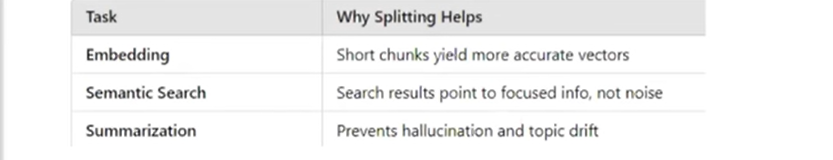

- Optimizing Computational Resources: Working with smaller chunks of text can bemore memory efficient & allow for better parallelization of processing tasks.

## Type of Text Splitters:
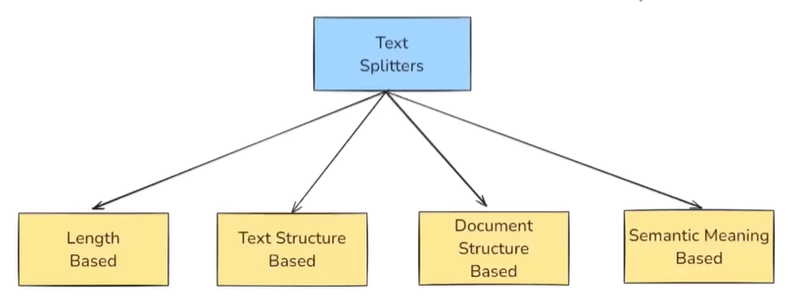

1. Length Based
2. Text Structure Based
3. Document Structure Based
4. Semantic Meaning Based

### 1. Length Based

In [1]:
from langchain_text_splitters import CharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader

# Loading the PDF document using PyPDFLoader
loader = PyPDFLoader('../../data/raw/dl-curriculum.pdf')
docs = loader.load()

# Splitting the loaded document
splitter = CharacterTextSplitter(
    chunk_size=200,
    chunk_overlap=0,
    separator=''
)

result = splitter.split_documents(docs)
print("Length of documents:\n", len(result))
print("Document Objects:\n", result)
print("----------" * 30)
print(result[1].page_content)
print("--------------"  * 30)

"""
CharacterTextSplitter - While splitting the document it will not consider linguistic 
structure, grammar, semantic meaning or any other factors. 
It will simply split the text based on the specified character count, 
regardless of the content or context of the text. This can lead to chunks that may 
not be semantically coherent or meaningful, as it does not take into account sentence 
boundaries, paragraphs, or any other natural language processing considerations.
"""

Length of documents:
 89
Document Objects:
 [Document(metadata={'producer': 'Skia/PDF m131 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'Deep Learning Curriculum', 'source': '../../data/raw/dl-curriculum.pdf', 'total_pages': 23, 'page': 0, 'page_label': '1'}, page_content='CampusXDeepLearningCurriculum\nA.ArtificialNeuralNetworkandhowtoimprovethem\n1.BiologicalInspiration\n● Understandingtheneuronstructure● Synapsesandsignal transmission● Howbiological conceptstranslatetoa'), Document(metadata={'producer': 'Skia/PDF m131 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'Deep Learning Curriculum', 'source': '../../data/raw/dl-curriculum.pdf', 'total_pages': 23, 'page': 0, 'page_label': '1'}, page_content='rtificial neurons\n2.HistoryofNeuralNetworks\n● Earlymodels(Perceptron)● BackpropagationandMLPs● The"AI Winter" andresurgenceof neural networks● Emergenceof deeplearning\n3.PerceptronandMultilayerPercept'), Document(metadata={'producer'

'\nCharacterTextSplitter - While splitting the document it will not consider linguistic \nstructure, grammar, semantic meaning or any other factors. \nIt will simply split the text based on the specified character count, \nregardless of the content or context of the text. This can lead to chunks that may \nnot be semantically coherent or meaningful, as it does not take into account sentence \nboundaries, paragraphs, or any other natural language processing considerations.\n'

### 2. Text-Structured Based

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text = """
Space exploration has led to incredible scientific discoveries. From landing on the Moon to exploring Mars, humanity continues to push the boundaries of what’s possible beyond our planet.

These missions have not only expanded our knowledge of the universe but have also contributed to advancements in technology here on Earth. Satellite communications, GPS, and even certain medical imaging techniques trace their roots back to innovations driven by space programs.
"""
 
splitter = RecursiveCharacterTextSplitter(
    chunk_size=50,
    chunk_overlap=0,
)
chunks = splitter.split_text(text)

print("Length of chunks:\n", len(chunks))
print("Chunks:\n", chunks)

"""
RecursiveCharacterTextSplitter - This splitter takes a more sophisticated approach to 
splitting text. It splits the text recursively, first trying to split it at 
natural boundaries i.e. paragraphs -> lines -> words -> characters.
"""

Length of chunks:
 11
Chunks:
 ['Space exploration has led to incredible', 'scientific discoveries. From landing on the Moon', 'to exploring Mars, humanity continues to push the', 'boundaries of what’s possible beyond our planet.', 'These missions have not only expanded our', 'knowledge of the universe but have also', 'contributed to advancements in technology here on', 'Earth. Satellite communications, GPS, and even', 'certain medical imaging techniques trace their', 'roots back to innovations driven by space', 'programs.']


'\nRecursiveCharacterTextSplitter - This splitter takes a more sophisticated approach to \nsplitting text. It splits the text recursively, first trying to split it at \nnatural boundaries i.e. paragraphs -> lines -> words -> characters.\n'

### 3. Document-Structured Based
Here we use recursive character text splitter only but we use different seperators for creating chunks

In [ ]:
# Example with Python code
from langchain_text_splitters import RecursiveCharacterTextSplitter,Language

text = """
class Student:
    def __init__(self, name, age, grade):
        self.name = name
        self.age = age
        self.grade = grade  # Grade is a float (like 8.5 or 9.2)

    def get_details(self):
        return self.name"

    def is_passing(self):
        return self.grade >= 6.0

# Example usage
student1 = Student("Aarav", 20, 8.2)
print(student1.get_details())

if student1.is_passing():
    print("The student is passing.")
else:
    print("The student is not passing.")

"""

splitter = RecursiveCharacterTextSplitter.from_language(
    language=Language.PYTHON,
    chunk_size=300,
    chunk_overlap=0,
)
chunks = splitter.split_text(text)

print("Length of chunks:", len(chunks))
print("First chunk:", chunks[1])
print("----------" * 30)
print("chunks", chunks)

Length of chunks: 2
First chunk: # Example usage
student1 = Student("Aarav", 20, 8.2)
print(student1.get_details())

if student1.is_passing():
    print("The student is passing.")
else:
    print("The student is not passing.")
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
chunks ['class Student:\n    def __init__(self, name, age, grade):\n        self.name = name\n        self.age = age\n        self.grade = grade  # Grade is a float (like 8.5 or 9.2)\n\n    def get_details(self):\n        return self.name"\n\n    def is_passing(self):\n        return self.grade >= 6.0', '# Example usage\nstudent1 = Student("Aarav", 20, 8.2)\nprint(student1.get_details())\n\nif student1.is_passing():\n    print("The student is passing.")\nelse:\n    pr

In [6]:
from langchain_text_splitters import RecursiveCharacterTextSplitter, Language

text = """
# Project Name: Smart Student Tracker

A simple Python-based project to manage and track student data, including their grades, age, and academic status.


## Features

- Add new students with relevant info
- View student details
- Check if a student is passing
- Easily extendable class-based design


## 🛠 Tech Stack

- Python 3.10+
- No external dependencies


## Getting Started

1. Clone the repo  
   ```bash
   git clone https://github.com/your-username/student-tracker.git

"""

# Initialize the splitter
splitter = RecursiveCharacterTextSplitter.from_language(
    language=Language.MARKDOWN,
    chunk_size=200,
    chunk_overlap=0,
)

# Perform the split
chunks = splitter.split_text(text)

print("Length of chunks:", len(chunks))
print("First chunk:", chunks[0])
print("Chunks:\n", chunks)

Length of chunks: 3
First chunk: # Project Name: Smart Student Tracker

A simple Python-based project to manage and track student data, including their grades, age, and academic status.
Chunks:
 ['# Project Name: Smart Student Tracker\n\nA simple Python-based project to manage and track student data, including their grades, age, and academic status.', '## Features\n\n- Add new students with relevant info\n- View student details\n- Check if a student is passing\n- Easily extendable class-based design', '## 🛠 Tech Stack\n\n- Python 3.10+\n- No external dependencies\n\n\n## Getting Started\n\n1. Clone the repo  \n   ```bash\n   git clone https://github.com/your-username/student-tracker.git']


### 4. Semantic Meaning Chunking

In [12]:
# from langchain_experimental.text_splitter import SemanticChunker
# from langchain_openai.embeddings import OpenAIEmbeddings
# from dotenv import load_dotenv

# load_dotenv()

# text_splitter = SemanticChunker(
#     OpenAIEmbeddings(), breakpoint_threshold_type="standard_deviation",
#     breakpoint_threshold_amount=3
# )

# sample = """
# Farmers were working hard in the fields, preparing the soil and planting seeds for the next season. The sun was bright, and the air smelled of earth and fresh grass. The Indian Premier League (IPL) is the biggest cricket league in the world. People all over the world watch the matches and cheer for their favourite teams.


# Terrorism is a big danger to peace and safety. It causes harm to people and creates fear in cities and villages. When such attacks happen, they leave behind pain and sadness. To fight terrorism, we need strong laws, alert security forces, and support from people who care about peace and safety.
# """

# docs = text_splitter.create_documents([sample])
# print(len(docs))
# print(docs)

